Name: MADHAN M 
Reg. No: 212225040213 
Ridge - Mean Squared Error: 0.26, R² Score: 0.79,Mean Absolute Error: 0.29
Lasso - Mean Squared Error: 0.94, R² Score: 0.25,Mean Absolute Error: 0.70
ElasticNet - Mean Squared Error: 0.63, R² Score: 0.49,Mean Absolute Error: 0.59


C:\Users\mynam\AppData\Local\Temp\ipykernel_1952\1295078960.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
C:\Users\mynam\AppData\Local\Temp\ipykernel_1952\1295078960.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


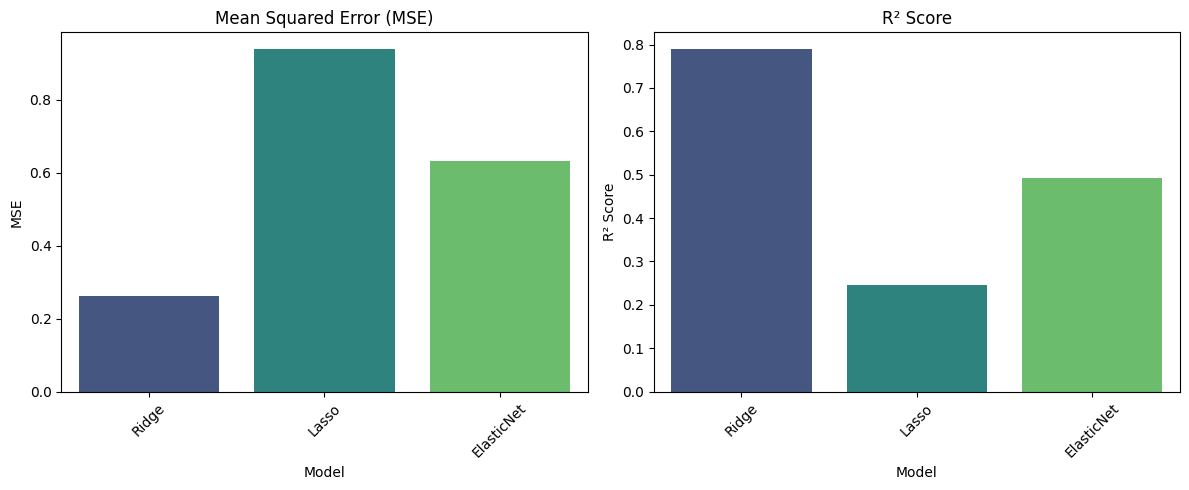

In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error


# Load the dataset
data = pd.read_csv("encoded_car_data (1).csv")
data.head()

# Data preprocessing
#data = data.drop(['CarName', 'car_ID'], axis=1)
data = pd.get_dummies(data, drop_first=True)

# Splitting the data into features and target variable
X = data.drop('price', axis=1)
y = data['price']


# Standardizing the features
scaler = StandardScaler()

X = scaler.fit_transform(X)
y = scaler.fit_transform(y.values.reshape(-1, 1))


# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the models and pipelines
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

# Dictionary to store results
results = {}


# Train and evaluate each model
for name, model in models.items():
    
    # Create a pipeline with polynomial features and the model
    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('regressor', model)
    ])
    
    # Fit the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    predictions = pipeline.predict(X_test)
    
    # Calculate performance metrics
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    mae=mean_absolute_error(y_test,predictions)
    
    # Store results
    results[name] = {'MSE': mse, 'R2 Score': r2,'MAE':mae}
# Print results
print('Name: MADHAN M ')
print('Reg. No: 212225040213 ')
for model_name, metrics in results.items():
    print(f"{model_name} - Mean Squared Error: {metrics['MSE']:.2f}, R² Score: {metrics['R2 Score']:.2f},Mean Absolute Error: {metrics['MAE']:.2f}")


# Visualization of the results

# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results).T
results_df.reset_index(inplace=True)
results_df.rename(columns={'index': 'Model'}, inplace=True)

# Set the figure size
plt.figure(figsize=(12, 5))

# Bar plot for MSE
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='MSE', data=results_df, palette='viridis')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xticks(rotation=45)


# Bar plot for R² Score
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=45)

# Show the plots
plt.tight_layout()
plt.show()